In [1]:
pip install mediapipe

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.1/36.1 MB 50.1 MB/s eta 0:00:00


In [2]:
import mediapipe as mp

In [3]:
!pip install -q mediapipe

In [4]:
!wget -O face_landmarker_v2_with_blendshapes.task -q https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
from google.colab import files
from mediapipe import solutions
from mediapipe.framework.formats import landmark_pb2
import numpy as np
import matplotlib.pyplot as plt
import cv2
from google.colab.patches import cv2_imshow
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

# Function to draw landmarks on image
def draw_landmarks_on_image(rgb_image, detection_result):
    face_landmarks_list = detection_result.face_landmarks
    annotated_image = np.copy(rgb_image)

    # Loop through the detected faces to visualize.
    for idx in range(len(face_landmarks_list)):
        face_landmarks = face_landmarks_list[idx]

        # Draw the face landmarks.
        face_landmarks_proto = landmark_pb2.NormalizedLandmarkList()
        face_landmarks_proto.landmark.extend([
            landmark_pb2.NormalizedLandmark(x=landmark.x, y=landmark.y, z=landmark.z) for landmark in face_landmarks
        ])

        solutions.drawing_utils.draw_landmarks(
            image=annotated_image,
            landmark_list=face_landmarks_proto,
            connections=mp.solutions.face_mesh.FACEMESH_TESSELATION,
            landmark_drawing_spec=None,
            connection_drawing_spec=mp.solutions.drawing_styles
            .get_default_face_mesh_tesselation_style())
        solutions.drawing_utils.draw_landmarks(
            image=annotated_image,
            landmark_list=face_landmarks_proto,
            connections=mp.solutions.face_mesh.FACEMESH_CONTOURS,
            landmark_drawing_spec=None,
            connection_drawing_spec=mp.solutions.drawing_styles
            .get_default_face_mesh_contours_style())
        solutions.drawing_utils.draw_landmarks(
            image=annotated_image,
            landmark_list=face_landmarks_proto,
            connections=mp.solutions.face_mesh.FACEMESH_IRISES,
            landmark_drawing_spec=None,
            connection_drawing_spec=mp.solutions.drawing_styles
            .get_default_face_mesh_iris_connections_style())

    return annotated_image

# Function to plot face blendshapes as a bar graph
def plot_face_blendshapes_bar_graph(face_blendshapes):
    # Extract the face blendshapes category names and scores.
    face_blendshapes_names = [face_blendshapes_category.category_name for face_blendshapes_category in face_blendshapes]
    face_blendshapes_scores = [face_blendshapes_category.score for face_blendshapes_category in face_blendshapes]
    # The blendshapes are ordered in decreasing score value.
    face_blendshapes_ranks = range(len(face_blendshapes_names))

    fig, ax = plt.subplots(figsize=(12, 12))
    bar = ax.barh(face_blendshapes_ranks, face_blendshapes_scores, label=[str(x) for x in face_blendshapes_ranks])
    ax.set_yticks(face_blendshapes_ranks)
    ax.set_yticklabels(face_blendshapes_names)
    ax.invert_yaxis()

    # Label each bar with values
    for score, patch in zip(face_blendshapes_scores, bar.patches):
        plt.text(patch.get_x() + patch.get_width(), patch.get_y(), f"{score:.4f}", va="top")

    ax.set_xlabel('Score')
    ax.set_title("Face Blendshapes")
    plt.tight_layout()
    plt.show()

# STEP 1: Upload the image using file upload
import os
path="/content/drive/MyDrive/datasetFinal"
files=os.listdir(path)
label="smile"
for f in files:
  print(f)
  if os.path.isdir(f):
    continue
  filename,ext=f.split(".")
  if ext not in ["jpg","png"]:
    continue
  image_path = path+f
  print("image path",image_path)
  # STEP 2: Initialize the FaceLandmarker object.
  base_options = python.BaseOptions(model_asset_path='face_landmarker_v2_with_blendshapes.task')
  options = vision.FaceLandmarkerOptions(base_options=base_options,
                                        output_face_blendshapes=True,
                                        output_facial_transformation_matrixes=True,
                                        num_faces=1)
  detector = vision.FaceLandmarker.create_from_options(options)

  # STEP 3: Load the input image.
  input_image = mp.Image.create_from_file(image_path)

  # STEP 4: Detect face landmarks and blendshapes.
  detection_result = detector.detect(input_image)

  # STEP 5: Process the detection result and visualize.
  annotated_image = draw_landmarks_on_image(input_image.numpy_view(), detection_result)

  # STEP 6: Plot the face blendshapes bar graph.
  result=[]
  for j in range(0,52):
    result.append(round(detection_result.face_blendshapes[0][j].score,3))
  result.append(label)
  print(result)

EyesClose


ValueError: not enough values to unpack (expected 2, got 1)

In [10]:
import os
import pandas as pd
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

# Function to process images and store results
def process_images_and_store_results(main_folder, model_path, output_excel):
    # Initialize Mediapipe FaceLandmarker
    base_options = python.BaseOptions(model_asset_path=model_path)
    options = vision.FaceLandmarkerOptions(
        base_options=base_options,
        output_face_blendshapes=True,
        output_facial_transformation_matrixes=True,
        num_faces=1
    )
    detector = vision.FaceLandmarker.create_from_options(options)

    # Prepare data for Excel
    results_data = []

    for subfolder in os.listdir(main_folder):
        subfolder_path = os.path.join(main_folder, subfolder)

        # Skip if not a directory
        if not os.path.isdir(subfolder_path):
            continue

        # Iterate over images in the subfolder
        for image_file in os.listdir(subfolder_path):
            image_path = os.path.join(subfolder_path, image_file)
            if not os.path.isfile(image_path):
                continue

            # Validate file extension
            ext = os.path.splitext(image_file)[1].lower()
            if ext not in [".jpg", ".png"]:
                continue

            # Process image with Mediapipe
            try:
                input_image = mp.Image.create_from_file(image_path)
                detection_result = detector.detect(input_image)

                # Extract blendshape scores
                if detection_result.face_blendshapes:
                    result = [round(detection_result.face_blendshapes[0][j].score, 3) for j in range(52)]
                    result.append(subfolder)  # Use subfolder name as the label
                    results_data.append(result)
            except Exception as e:
                print(f"Error processing image {image_path}: {e}")

    # Create DataFrame and save to Excel
    blendshape_columns = [f"Blendshape_{i}" for i in range(52)] + ["Label"]
    df = pd.DataFrame(results_data, columns=blendshape_columns)
    df.to_excel(output_excel, index=False)
    print(f"Results saved to {output_excel}")

# Main configuration
main_folder = "/content/drive/MyDrive/datasetFinal"  # Path to the main folder
model_path = "face_landmarker_v2_with_blendshapes.task"  # Path to the Mediapipe model
output_excel = "/content/blendshapes_results.xlsx"  # Output Excel file

# Run the processing function
process_images_and_store_results(main_folder, model_path, output_excel)


Results saved to /content/blendshapes_results.xlsx


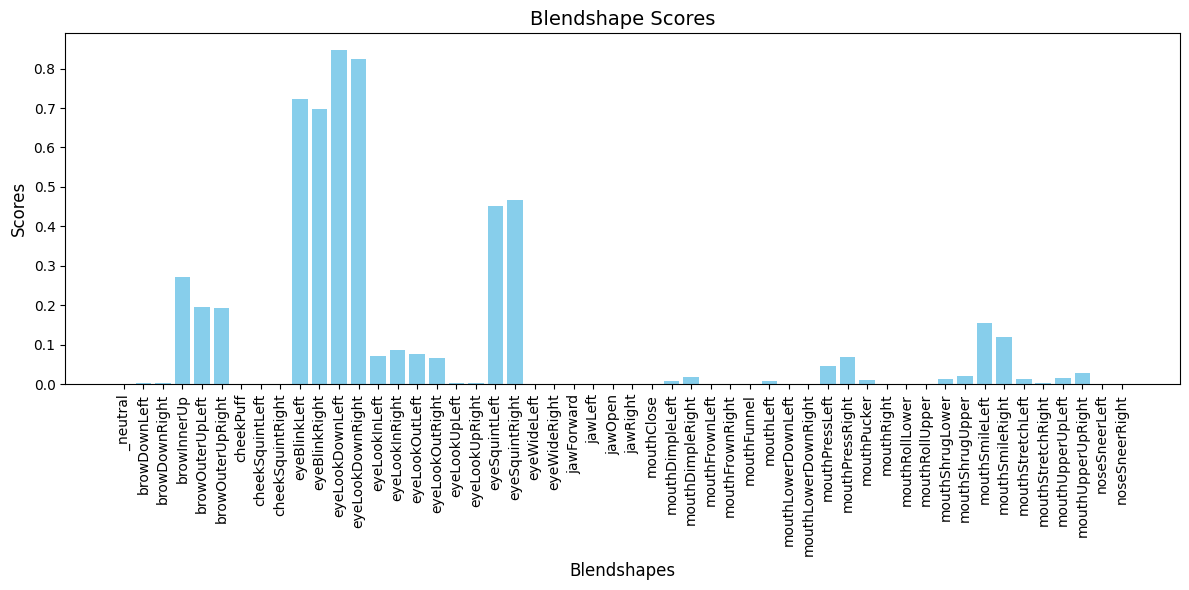

In [11]:
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import matplotlib.pyplot as plt

# Function to process a single image and plot the blendshape scores
def process_image_and_plot_blendshapes(image_path, model_path):
    # Step 1: Initialize the FaceLandmarker
    base_options = python.BaseOptions(model_asset_path=model_path)
    options = vision.FaceLandmarkerOptions(
        base_options=base_options,
        output_face_blendshapes=True,
        output_facial_transformation_matrixes=True,
        num_faces=1
    )
    detector = vision.FaceLandmarker.create_from_options(options)

    # Step 2: Load the input image
    input_image = mp.Image.create_from_file(image_path)

    # Step 3: Detect face landmarks and blendshapes
    detection_result = detector.detect(input_image)

    # Step 4: Extract and visualize blendshape scores
    if detection_result.face_blendshapes:
        blendshapes = detection_result.face_blendshapes[0]
        scores = [round(blendshape.score, 3) for blendshape in blendshapes]
        names = [blendshape.category_name for blendshape in blendshapes]

        # Plot the scores as a bar graph
        plt.figure(figsize=(12, 6))
        plt.bar(names, scores, color='skyblue')
        plt.xticks(rotation=90, fontsize=10)
        plt.xlabel('Blendshapes', fontsize=12)
        plt.ylabel('Scores', fontsize=12)
        plt.title('Blendshape Scores', fontsize=14)
        plt.tight_layout()
        plt.show()
    else:
        print("No face or blendshapes detected in the image.")

# Configuration
image_path = "/content/drive/MyDrive/datasetFinal/EyesClose/1.jpg"  # Path to the image
model_path = "face_landmarker_v2_with_blendshapes.task"  # Path to Mediapipe model

# Run the function
process_image_and_plot_blendshapes(image_path, model_path)


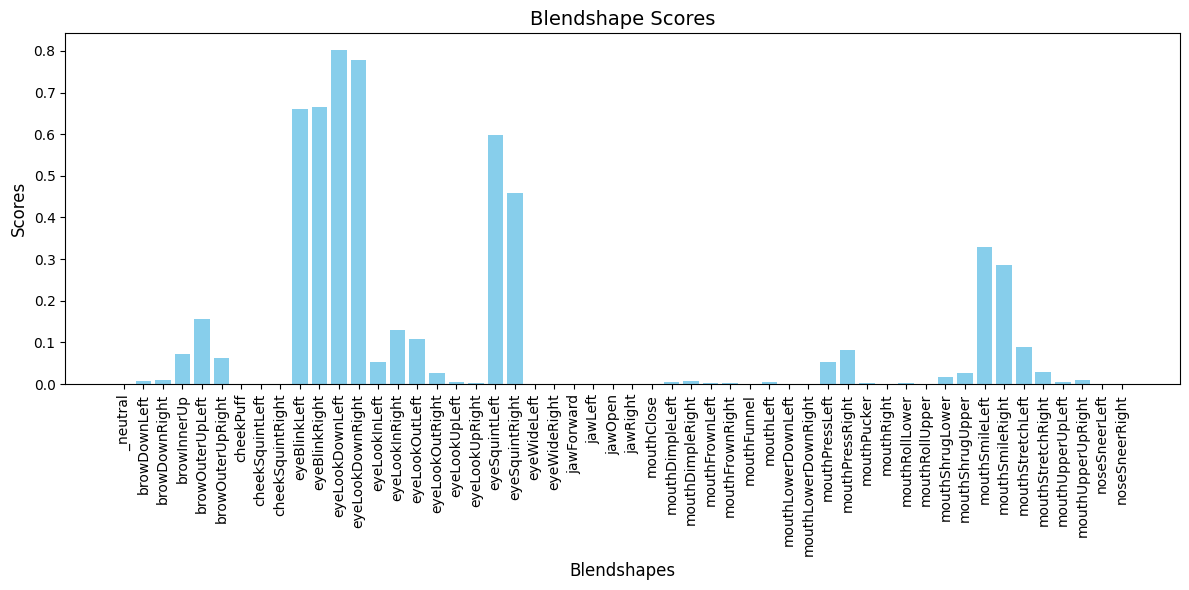

In [13]:
image_path = "/content/drive/MyDrive/datasetFinal/EyesClose/10.jpg"
process_image_and_plot_blendshapes(image_path, model_path)

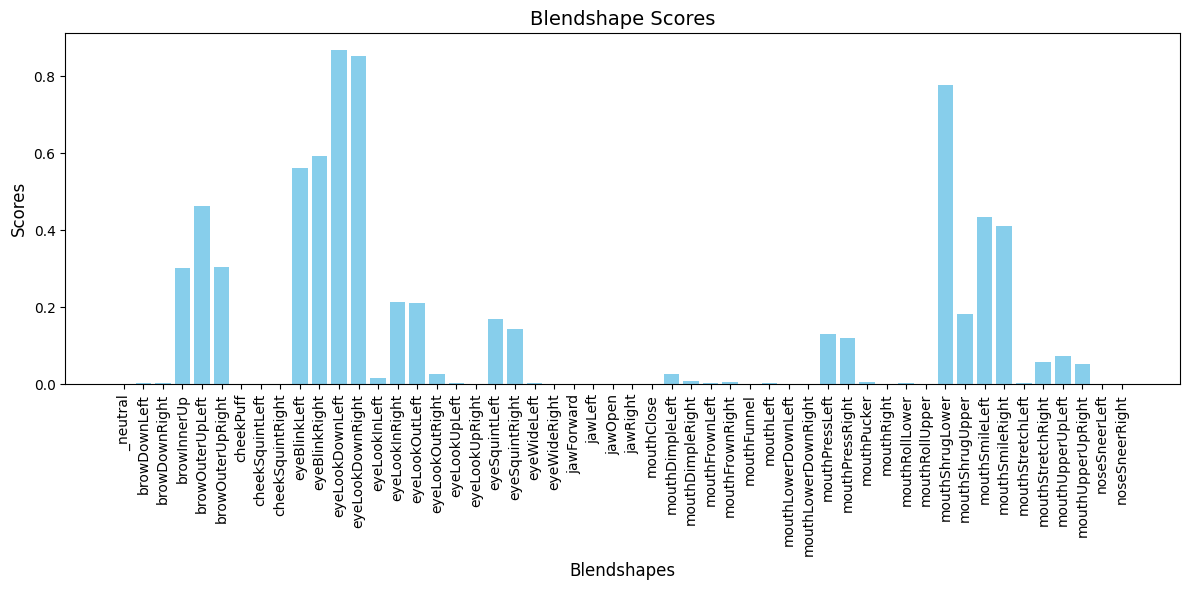

In [14]:
image_path = "/content/drive/MyDrive/datasetFinal/EyesClose/100.jpg"
process_image_and_plot_blendshapes(image_path, model_path)

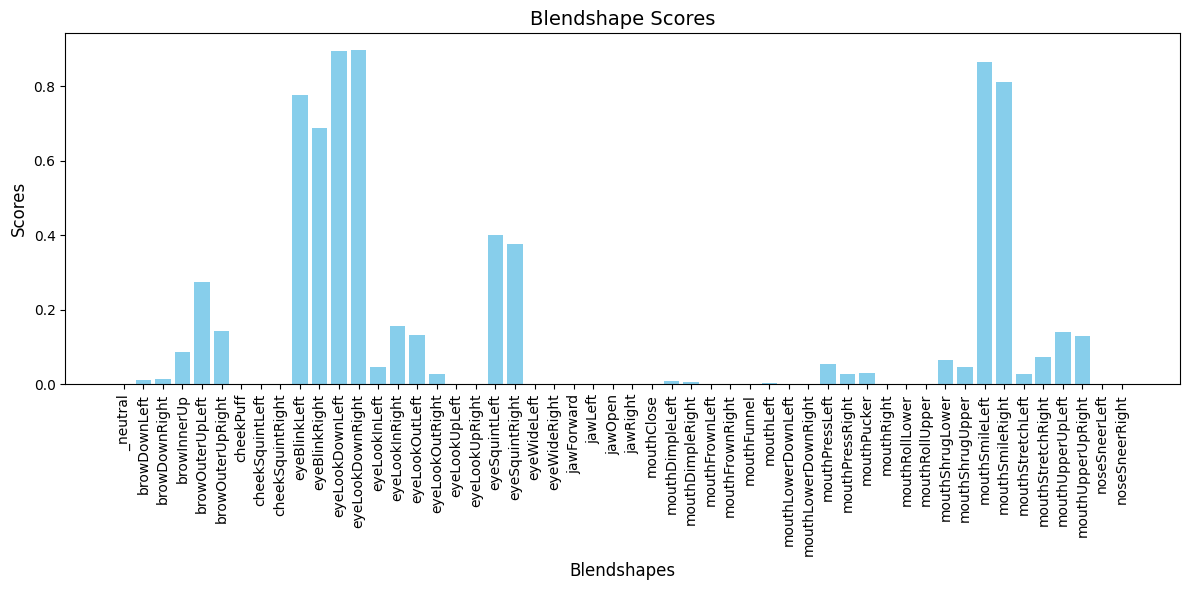

In [15]:
image_path = "/content/drive/MyDrive/datasetFinal/EyesClose/105.jpg"
process_image_and_plot_blendshapes(image_path, model_path)

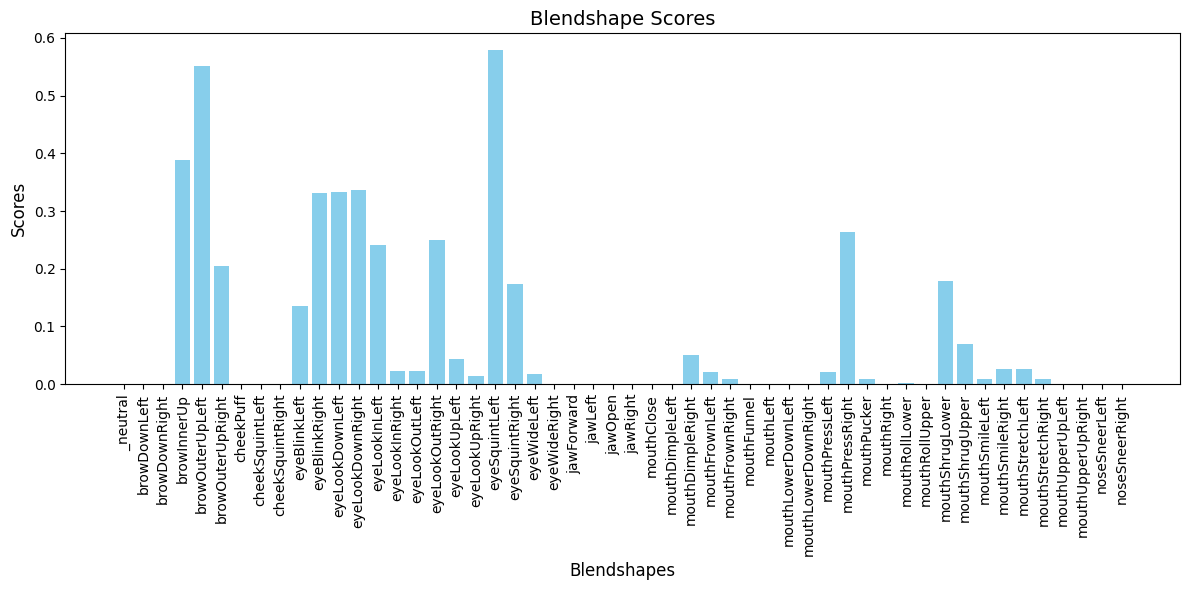

In [16]:
image_path = "/content/drive/MyDrive/datasetFinal/HeadSlantLeft/1.jpg"
process_image_and_plot_blendshapes(image_path, model_path)

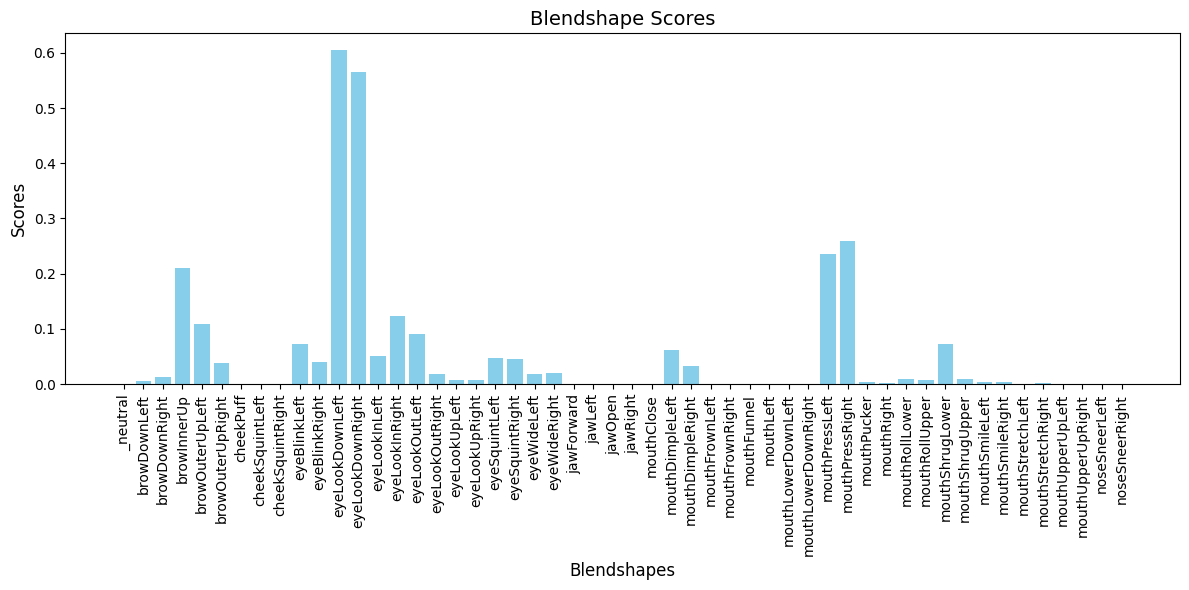

In [17]:
image_path = "/content/drive/MyDrive/datasetFinal/HeadSlantLeft/10.jpg"
process_image_and_plot_blendshapes(image_path, model_path)

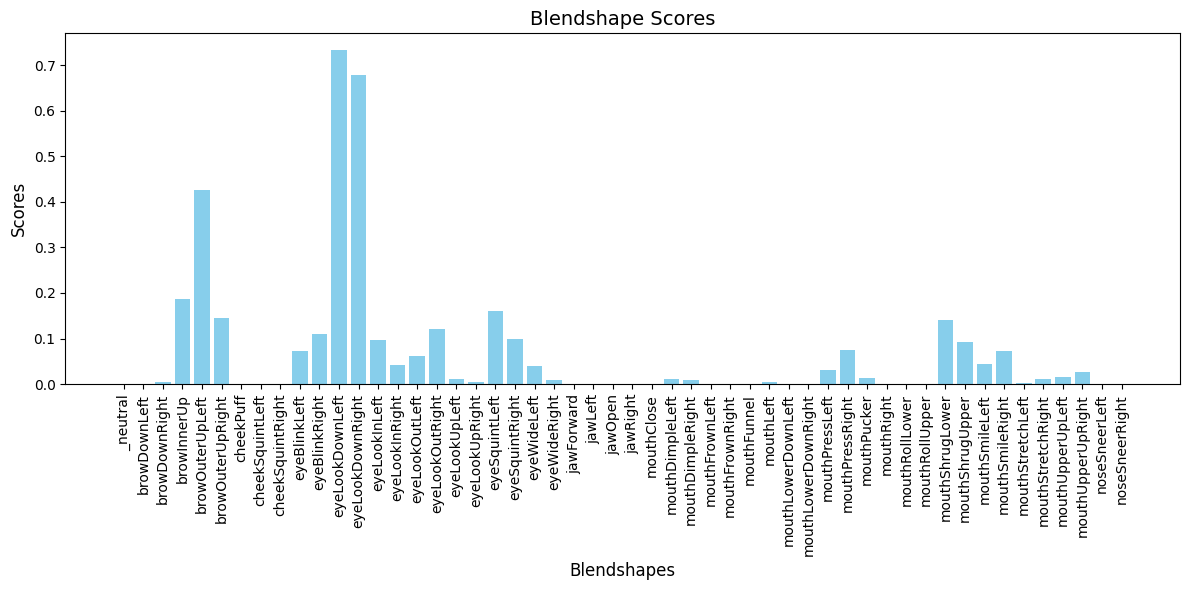

In [18]:
image_path = "/content/drive/MyDrive/datasetFinal/HeadSlantLeft/103.jpg"
process_image_and_plot_blendshapes(image_path, model_path)